In [1]:
import sys
import os
import torch
sys.path.append(os.path.abspath('../'))

from src.models.single_network import SingleNetwork
from src.models.mc_dropout import MCDropout
from src.models.deep_ensemble import DeepEnsemble
from src.training.trainer import ModelTrainer
from src.processing.preprocess import get_dataloaders_for_sipakmed, getdataframe_for_sipakmed
from src.processing.loading import load_image_folder
from src.utils.visualisation import plot_performance_curves, plot_metrics_performance, ReliabilityPlotter
import pandas as pd
import matplotlib.pyplot as plt


`{im_Dyskeratotic: 0, im_Koilocytic: 1, im_Metaplasticimage_path: 2, im_Parabasal:3, im_Superficial-Intermediate: 4}`

In [2]:
train_loader, val_loader, cal_loader, test_loader = get_dataloaders_for_sipakmed(batch_size=32, num_workers=4, model_type="resnet")


df_all = getdataframe_for_sipakmed(train_loader, val_loader, cal_loader, test_loader)
df_all

,subset,image_path,label
0,train,/home/conite/Documents/STAGE/HybridUncertainty...,1
1,train,/home/conite/Documents/STAGE/HybridUncertainty...,0
2,train,/home/conite/Documents/STAGE/HybridUncertainty...,4
3,train,/home/conite/Documents/STAGE/HybridUncertainty...,0
4,train,/home/conite/Documents/STAGE/HybridUncertainty...,4
...,...,...,...
4044,test,/home/conite/Documents/STAGE/HybridUncertainty...,2
4045,test,/home/conite/Documents/STAGE/HybridUncertainty...,4
4046,test,/home/conite/Documents/STAGE/HybridUncertainty...,2
4047,test,/home/conite/Documents/STAGE/HybridUncertainty...,3


In [3]:
single_net = SingleNetwork(
    num_classes=5,
    learning_rate=5e-4,
    patience=5,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_loader=train_loader,
    val_loader=val_loader,
    cal_loader=cal_loader,
    test_loader=test_loader,
    
)

mcdropout = MCDropout(
    num_classes=5,
    learning_rate=5e-4,
    patience=5,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_loader=train_loader,
    val_loader=val_loader,
    cal_loader=cal_loader,
    test_loader=test_loader,
    
)

deepensemble = DeepEnsemble(
    num_classes=5,
    learning_rate=5e-4,
    patience=5,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_loader=train_loader,
    val_loader=val_loader,
    cal_loader=cal_loader,
    test_loader=test_loader,
    
)


/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /opt/conda/conda-bld/pytorch_1724789115370/work/c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50

**1.0 Evaluation**

In [4]:
# single_net.train(epochs=50, model_path='single_net_resnet_sipakmed.pth')
single_net.load('../experiments/results/sipakmed/output_single_resnet50_sipakmed.pth')
results_sn = single_net.evaluate()
print(f"Accuracy: {results_sn['accuracy']} | F1: {results_sn['f1_score']} | Precision: {results_sn['precision']} | Recall: {results_sn['recall']} | Brier: {results_sn['brier_score']} ")

/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/models/base_model.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(pa

Accuracy: 0.9720394736842105 | F1: 0.9720882585113793 | Precision: 0.9725019582066006 | Recall: 0.9720394736842105 | Brier: 0.044523559510707855 


In [5]:
mcdropout.load('../experiments/results/sipakmed/output_mcdropout_resnet50_sipakmed.pth')
results_mcd = mcdropout.evaluate()
print(f"Accuracy: {results_mcd['accuracy']} | F1: {results_mcd['f1_score']} | Precision: {results_mcd['precision']} | Recall: {results_mcd['recall']} | Brier: {results_mcd['brier_score']} ")

/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/models/base_model.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(pa

Accuracy: 0.9720394736842105 | F1: 0.9720882585113793 | Precision: 0.9725019582066006 | Recall: 0.9720394736842105 | Brier: 0.044523559510707855 


In [6]:
deepensemble.load([
    f"/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_{i}.pth" for i in range(5)
])
results_de = deepensemble.evaluate()
print(f"Accuracy: {results_de['accuracy']} | F1: {results_de['f1_score']} | Precision: {results_de['precision']} | Recall: {results_de['recall']} | Brier: {results_de['brier_score']} ")


/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/models/deep_ensemble.py:116: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(model_path, map_location=

Model 1 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_0.pth
Model 2 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_1.pth
Model 3 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_2.pth
Model 4 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_3.pth
Model 5 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_4.pth

🔎 Predicting with ensemble member 1/5



🔎 Predicting with ensemble member 2/5



🔎 Predicting with ensemble member 3/5



🔎 Predicting with ensemble member 4/5



🔎 Predicting with ensemble member 5/5


Accuracy: 0.9917763157894737 | F1: 0.9917693469346797 | Precision: 0.9917760834820101 | Recall: 0.9917763157894737 | Brier: 0.017302077263593674 


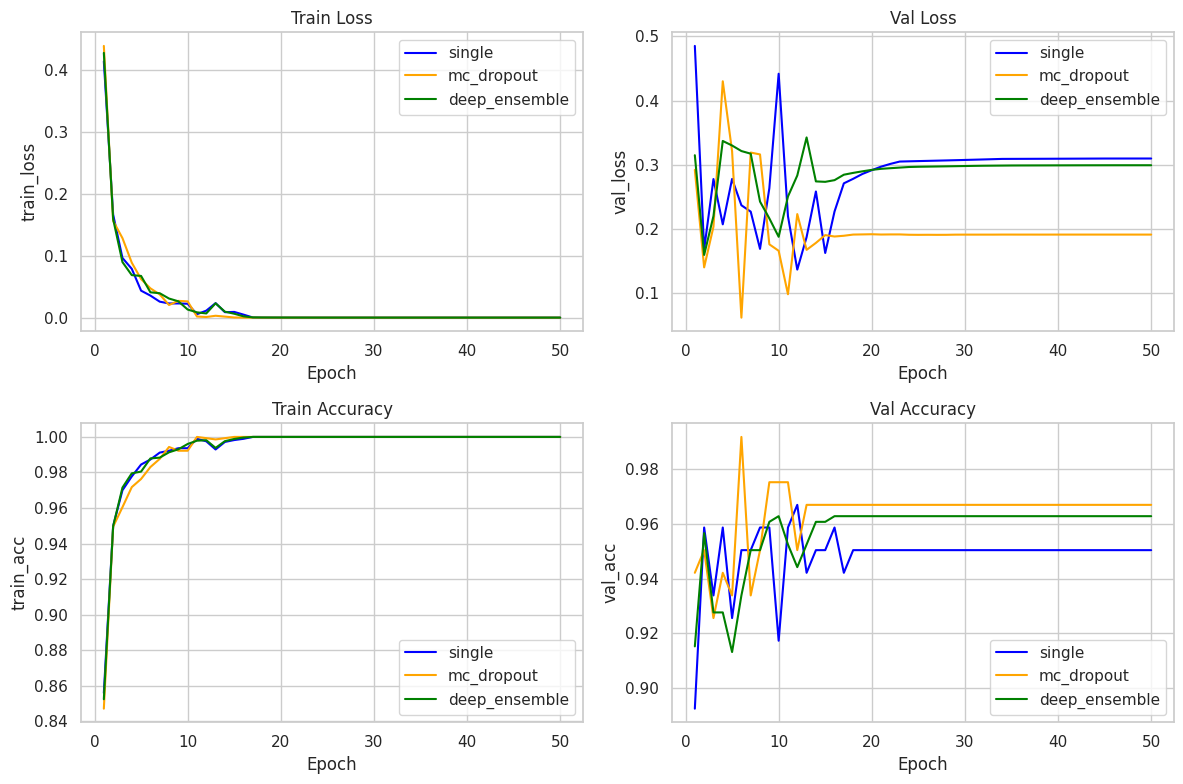

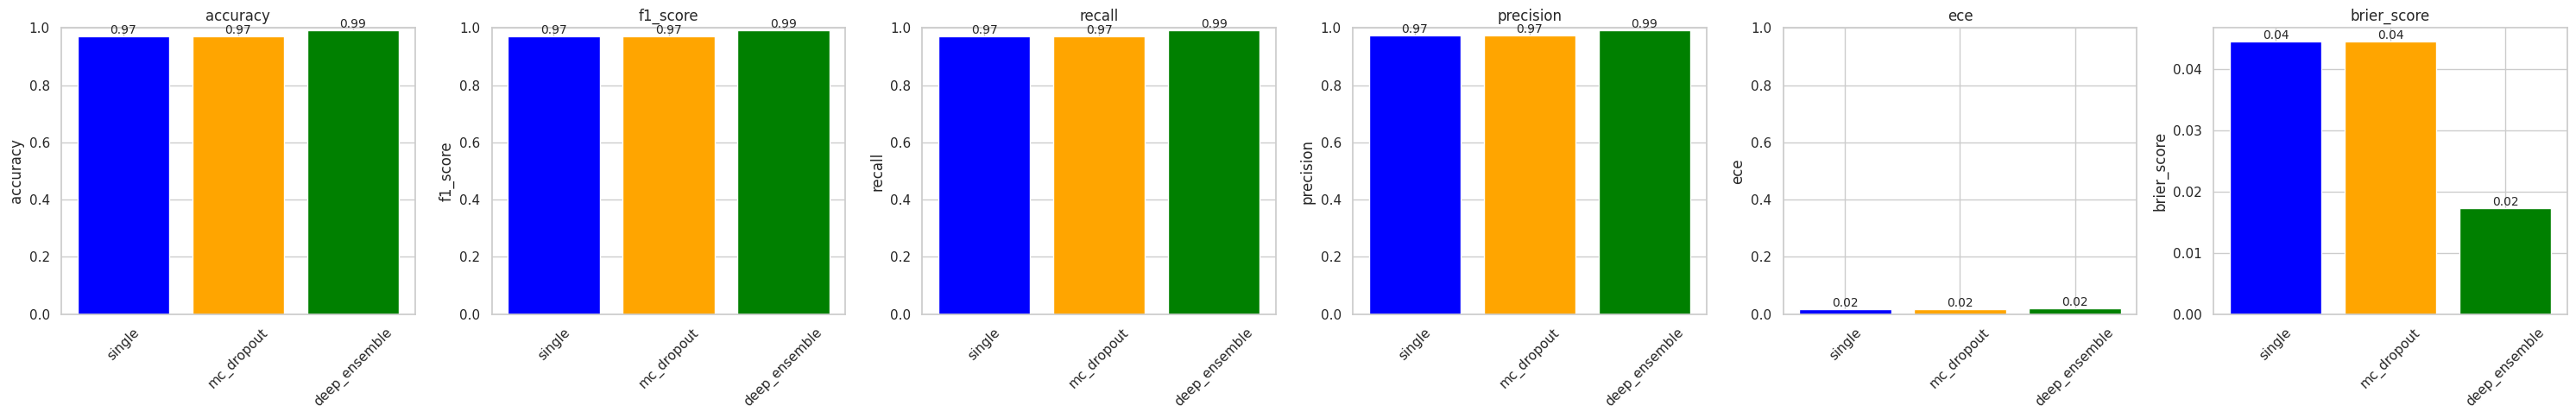

In [7]:
ENSEMBLE_SIZE = 5
path_results = {
    'single': os.path.join("/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_single_resnet50_sipakmed.json"),
    
    'mc_dropout': os.path.join("/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_mcdropout_resnet50_sipakmed.json"),
    'deep_ensemble': [
        os.path.join(f"/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_{i}.json") 
        for i in range(1,ENSEMBLE_SIZE)
    ]
}

gather_results = {
    'single': results_sn,
    'mc_dropout': results_mcd,
    'deep_ensemble': results_de
}


plot_performance_curves(path_results=path_results)
plot_metrics_performance(gather_results)

**Step 2: Analyze each model's calibration performance (e.g., via ECE, Brier score), identifying which base approach is best calibrated across the three datasets**


Plotting reliability diagram for approach: single


<Figure size 600x500 with 0 Axes>

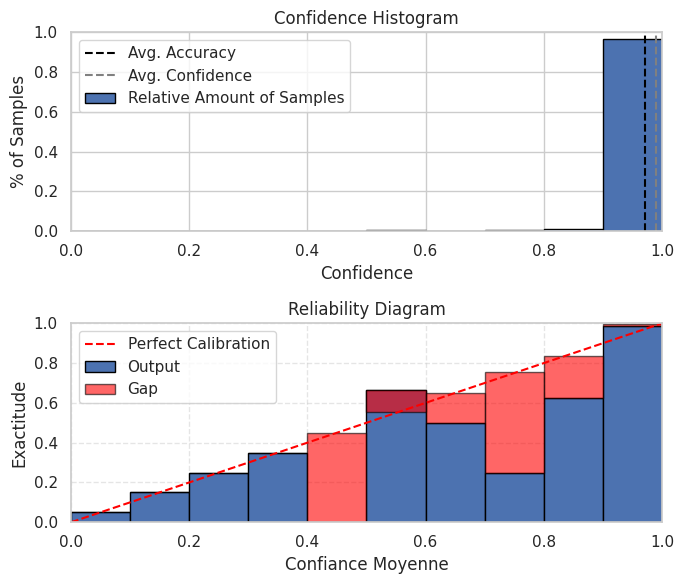

Plotting reliability diagram for approach: mc_dropout


<Figure size 600x500 with 0 Axes>

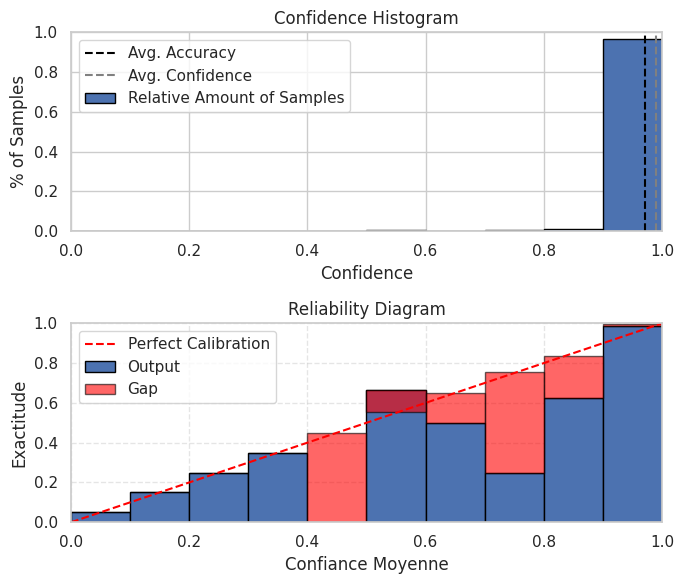

Plotting reliability diagram for approach: deep_ensemble


<Figure size 600x500 with 0 Axes>

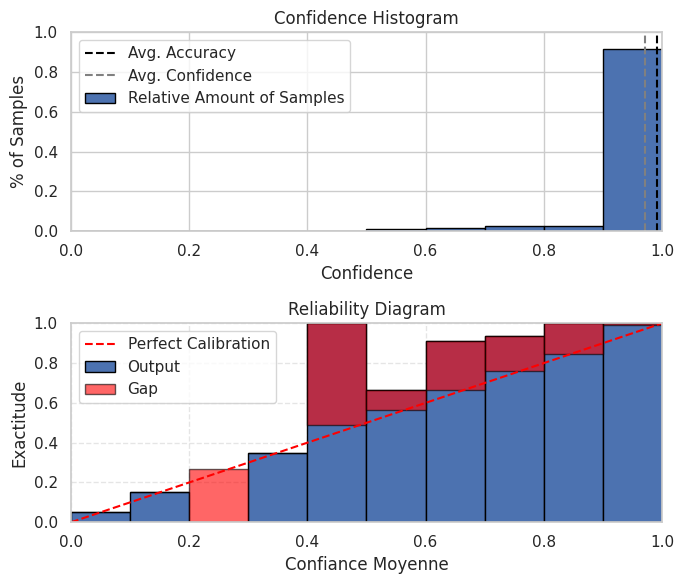

In [8]:
approaches_data = {
    'single': (results_sn['y_labels'], results_sn['y_probs']),
    'mc_dropout': (results_mcd['y_labels'], results_mcd['y_probs']),
    'deep_ensemble': (results_de['y_trues'], results_de['y_probs'])
}

plotter = ReliabilityPlotter(approaches_data)
plotter.plot_all_approaches(n_bins=10)

**Step 3: For each base method's (SingleNet, MCD, DE), apply APS, RAPS, and SAPS to create conformal sets, then compare their mean/median set sizes, marginal coverage, etc... and accuracy-per-set-size trade-offs to come out with the most efficient combinaison strategy on the three datasets.**

In [ ]:
# from src.conformal_prediction.cp_old import ConformalPredictor

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class ConformalPredictor:
    def __init__(self, method='raps', lambda_param=1.0, k_reg=1, randomize=True, dynamic_threshold_fn=None):
        """
        Paramètres :
          - method : 'raps' ou 'saps'
          - lambda_param : hyperparamètre de régularisation (λ)
          - k_reg : paramètre de seuil pour la régularisation (k₍reg₎)
          - randomize : si True, on utilise la randomisation (u ~ U(0,1))
        """
        self.method = method.lower()
        self.lambda_param = lambda_param
        self.k_reg = k_reg
        self.randomize = randomize
        self.tau = None
        self.dynamic_threshold_fn = dynamic_threshold_fn

        

    def _compute_aps_score(self, probs, true_label, u=None):

        sorted_indices = np.argsort(probs)[::-1]
        pos = np.where(sorted_indices == true_label)[0][0]
        score = np.sum(probs[sorted_indices[:pos]]) + u*probs[true_label] 
        
        return score

    
    def _compute_raps_score(self, probs, true_label, u):
        """
        Calcule le score RAPS pour un échantillon de calibration.
        Selon la formule :
          score = ρ(x,y) + π̂(x)[y]·u + λ·max(r - k_reg, 0)
        où ρ(x,y) est la somme cumulée des probabilités des classes mieux classées que y,
        et r est le rang (1-indexé) de y dans l'ordre décroissant.
        """
        sorted_indices = np.argsort(probs)[::-1]
        sorted_probs = probs[sorted_indices]
        rank = np.where(sorted_indices == true_label)[0][0] + 1
        rho = 0.0 if rank == 1 else np.sum(sorted_probs[:rank-1])
        score = rho + probs[true_label] * u + self.lambda_param * max(rank - self.k_reg, 0)
        return score

    def _compute_saps_score(self, probs, true_label, u):
        """
        Calcule le score SAPS pour un échantillon de calibration.
        Pour la classe ayant le rang 1, score = u * MSP.
        Sinon, score = MSP + (r - 2 + u)*λ,
        où MSP est la valeur maximale de la softmax, et r est le rang de la vraie classe.
        """
        max_prob = np.max(probs)
        sorted_indices = np.argsort(probs)[::-1]
        rank = np.where(sorted_indices == true_label)[0][0] + 1
        if rank == 1:
            score = u * max_prob
        else:
            score = max_prob + (rank - self.k_reg + u) * self.lambda_param
        return score

    def _compute_gaps_score(self, probs, true_label, u):
        """
        Compute GAP-based calibration score for conformal calibration.

        Logic:
        - For top-ranked class (rank=1), score = u * ConfidenceGap
        - For classes with rank > 1:
            score = ConfidenceGap + (rank - k_reg + u) * lambda_param

        Args:
            probs (array): predicted class probabilities.
            true_label (int): true class label.
            u (float): randomization uniform(0,1).

        Returns:
            float: GAP-based calibration score.
        """
        sorted_indices = np.argsort(probs)[::-1]
        p1, p2 = probs[sorted_indices[0]], probs[sorted_indices[1]]
        gap = p1 - p2
        rank = np.where(sorted_indices == true_label)[0][0] + 1

        if rank == 1:
            score = u * gap
        else:
            score = gap + (rank - self.k_reg + u) * self.lambda_param

        return score

    def compute_geaps_score(self, probs, true_label, u):
        """
        Compute GEAPS score (Gaps + Entropy) for a calibration sample.

        Replaces random u by normalized entropy.

        Args:
            probs (np.ndarray): Probability vector (shape: [K])
            true_label (int): Ground-truth class

        Returns:
            float: Conformal score
        """
        K = len(probs)
        sorted_indices = np.argsort(probs)[::-1]
        p1, p2 = probs[sorted_indices[0]], probs[sorted_indices[1]]
        gap = p1 - p2
        rank = np.where(sorted_indices == true_label)[0][0] + 1
        entropy = -np.sum(probs * np.log(probs + 1e-12))
        u = 1-(entropy / np.log(K))
        if rank == 1:
            score = u * gap
        else:
            score = gap + (rank - self.k_reg + u) * self.lambda_param
        return score
    
    def _compute_eaps_score(self, probs, true_label, u):
        
        K = len(probs)
        sorted_indices = np.argsort(probs)[::-1]
        p1, p2 = probs[sorted_indices[0]], probs[sorted_indices[1]]
        gap = p1 - p2
        rank = np.where(sorted_indices == true_label)[0][0] + 1
        entropy = -np.sum(probs * np.log(probs + 1e-12))
        prob = 1-(entropy / np.log(K))
        if rank == 1:
            score = prob
        else:
            score = prob + (rank - self.k_reg + u) * self.lambda_param
        return score

        
    def calibrate(self, cal_probs, cal_labels, cal_yvars, alpha=0.1):
        scores = []
        n = len(cal_labels)
        for i in range(n):
            u = np.random.uniform(0, 1) if self.randomize else 0.5
            if self.method == 'raps':
                score = self._compute_raps_score(cal_probs[i], cal_labels[i], u)
            elif self.method == 'saps':
                score = self._compute_saps_score(cal_probs[i], cal_labels[i], u)
            elif self.method == 'aps':
                score = self._compute_aps_score(cal_probs[i], cal_labels[i], u)
            elif self.method == 'gaps':
                score = self._compute_gaps_score(cal_probs[i], cal_labels[i], u)
            elif self.method == 'geaps':
                score = self.compute_geaps_score(cal_probs[i], cal_labels[i], u)
            elif self.method == 'eaps':
                score = self._compute_eaps_score(cal_probs[i], cal_labels[i], u)
            else:
                raise ValueError("Méthode non supportée : " + self.method)
            scores.append(score)
        scores = np.array(scores)
        sorted_scores = np.sort(scores)
        index = int(np.ceil((n + 1) * (1 - alpha))) - 1
        index = min(index, n - 1)
        self.tau = sorted_scores[index]
        return self.tau

    def _extract_uncertainty_feature(self, probs):
        entropy = -np.sum(probs * np.log(probs + 1e-12))
        return entropy / np.log(len(probs))


    def predict(self, probs):
        # === 1. Threshold dynamique ou statique ===
        if self.dynamic_threshold_fn is not None:
            input_feat = self._extract_uncertainty_feature(probs)
            threshold = self.dynamic_threshold_fn(torch.tensor([[input_feat]], dtype=torch.float32))
        else:    
            if self.tau is None:
                raise ValueError("Veuillez d'abord calibrer le prédicteur (méthode calibrate).")
            print("tau : ", self.tau)
            threshold = self.tau

        # === 2. Cast sécurité ===
        if isinstance(threshold, torch.Tensor):
            threshold = threshold.item()
        elif isinstance(threshold, np.ndarray):
            threshold = float(threshold.squeeze())
        elif not isinstance(threshold, float):
            raise TypeError(f"Threshold must be float-compatible, got {type(threshold)}")


        K = len(probs)
        
        if self.method == 'raps':
            sorted_indices = np.argsort(probs)[::-1]
            sorted_probs = probs[sorted_indices]
            cum_sum = 0.0
            L = 0
            for j in range(K):
                cum_sum += sorted_probs[j]
                penalty = self.lambda_param * max(j - self.k_reg, 0)
                if cum_sum + penalty > threshold:    
                    L = j + 1
                    break
            if L == 0:
                L = 1
            if self.randomize:
                s_L = sorted_probs[L - 1]
                extra_penalty = self.lambda_param if (L > self.k_reg) else 0
                delta = (cum_sum + extra_penalty - threshold) / (s_L + extra_penalty + 1e-12)

                if np.random.uniform(0, 1) >= delta and L > 1:
                    L = L - 1
            pred_set = sorted_indices[:L]

        elif self.method == 'saps':
            sorted_indices = np.argsort(probs)[::-1]
            max_prob = np.max(probs)
            u_list = np.random.uniform(0, 1, size=K) if self.randomize else np.full(K, 0.5)
            scores = []
            for j, idx in enumerate(sorted_indices):
                rank = j + 1
                if rank == 1:
                    score = u_list[j] * max_prob
                else:
                    score = max_prob + (rank - self.k_reg + u_list[j]) * self.lambda_param
                scores.append(score)
            scores = np.array(scores)
            L = 0
            for j in range(K):
                if scores[j] <= threshold:
                    L = j + 1
                else:
                    break
                
            if L == 0:
                L = 1
            pred_set = sorted_indices[:L]
            
        elif self.method == 'aps':
            sorted_indices = np.argsort(probs)[::-1]
            sorted_probs = probs[sorted_indices]
            cum_sum = 0.0
            L = 0
            for j in range(K):
                cum_sum += sorted_probs[j]
                print(f" threshold : {threshold} ")
                if cum_sum >= threshold:
                    L = j + 1
                    break
            

            pred_set = sorted_indices[:L]
            
            
        elif self.method == 'gaps':
            sorted_indices = np.argsort(probs)[::-1]
            p1, p2 = probs[sorted_indices[0]], probs[sorted_indices[1]]
            gap = p1 - p2

            u_list = np.random.uniform(0, 1, size=K) if self.randomize else np.full(K, 0.5)
            scores = []

            for j, idx in enumerate(sorted_indices):
                rank = j + 1
                if rank == 1:
                    score = u_list[j] * gap
                else:
                    score = gap + (rank - self.k_reg + u_list[j]) * self.lambda_param
                scores.append(score)

            scores = np.array(scores)

            L = 0
            for j in range(K):
                if scores[j] <= self.tau:
                    L = j + 1
                else:
                    break

            if L == 0:
                L = 1  
            pred_set = sorted_indices[:L]
        
        elif self.method == 'geaps':
            sorted_indices = np.argsort(probs)[::-1]
            p1, p2 = probs[sorted_indices[0]], probs[sorted_indices[1]]
            gap = p1 - p2
            entropy = -np.sum(probs * np.log(probs + 1e-12))
            prob = 1 - (entropy / np.log(K))
            scores = []
            for j, idx in enumerate(sorted_indices):
                rank = j + 1
                if rank == 1:
                    score = prob * gap
                else:
                    score = gap + (rank - self.k_reg + prob) * self.lambda_param
                scores.append(score)
            scores = np.array(scores)
            L = 0
            for j in range(K):
                if scores[j] <= self.tau:
                    L = j + 1
                else:
                    break
            if L == 0:
                L = 1
            pred_set = sorted_indices[:L]

        elif self.method == 'eaps':
            u_list = np.random.uniform(0, 1, size=K) if self.randomize else np.full(K, 0.5)
            
            sorted_indices = np.argsort(probs)[::-1]
            p1, p2 = probs[sorted_indices[0]], probs[sorted_indices[1]]
            gap = p1 - p2
            entropy = -np.sum(probs * np.log(probs + 1e-12))
            prob = 1 - (entropy / np.log(K))
            scores = []
            for j, idx in enumerate(sorted_indices):
                rank = j + 1
                if rank == 1:
                    score = prob
                else:
                    score = prob + (rank - self.k_reg + u_list[j]) * self.lambda_param
                scores.append(score)
            scores = np.array(scores)
            L = 0
            for j in range(K):
                if scores[j] <= self.tau:
                    L = j + 1
                else:
                    break
            if L == 0:
                L = 1
            pred_set = sorted_indices[:L]

        else:
            raise ValueError("Méthode non supportée : " + self.method)
            
        return pred_set, sorted_indices
    


alpha = 0.05
predictors = {
    'APS': ConformalPredictor(method='aps', lambda_param=0, k_reg=0, randomize=True),
    'RAPS': ConformalPredictor(method='raps', lambda_param=0.75, k_reg=2, randomize=False),
    'SAPS': ConformalPredictor(method='saps', lambda_param=0.75, k_reg=2, randomize=True),
    'GAPS': ConformalPredictor(method='gaps', lambda_param=0.75, k_reg=2, randomize=True),
    'EAPS': ConformalPredictor(method='eaps', lambda_param=0.75, k_reg=2, randomize=True),
    'GEAPS': ConformalPredictor(method='geaps', lambda_param=0.75, k_reg=2, randomize=True),
}

for predictor_name, predictor in predictors.items():
    print(f"Calibrating {predictor_name}")
    cal_probs = results_sn['y_probs']
    cal_labels = results_sn['y_labels']
    cal_vars = results_sn['y_variances']    
    predictor.calibrate(cal_probs, cal_labels, cal_vars, alpha=alpha)
    print(f"Best tau: {predictor.tau}")


Calibrating APS
Best tau: 0.9522531671572427
Calibrating RAPS
Best tau: 0.5
Calibrating SAPS
Best tau: 0.9709505966244469
Calibrating GAPS
Best tau: 0.973992855514718
Calibrating EAPS
Best tau: 1.0
Calibrating GEAPS
Best tau: 1.0


 <======================Single approach======================>
tau :  0.9522531671572427
 cum_sum : [[2.55959315e-18 1.00000000e+00 3.90732334e-14 1.94912154e-20
  1.28917457e-14]
 [1.00000000e+00 5.75905187e-18 5.08562943e-23 2.16613981e-20
  6.52819281e-28]
 [1.20200135e-20 2.78137634e-14 1.00000000e+00 4.35488321e-12
  3.68189711e-16]
 [7.76406970e-16 5.43006924e-11 1.00000000e+00 2.14289675e-09
  1.85266017e-12]
 [8.71480280e-24 2.09409984e-16 1.00000000e+00 6.63587701e-14
  1.63030020e-18]] | threshold : 0.9522531671572427 


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

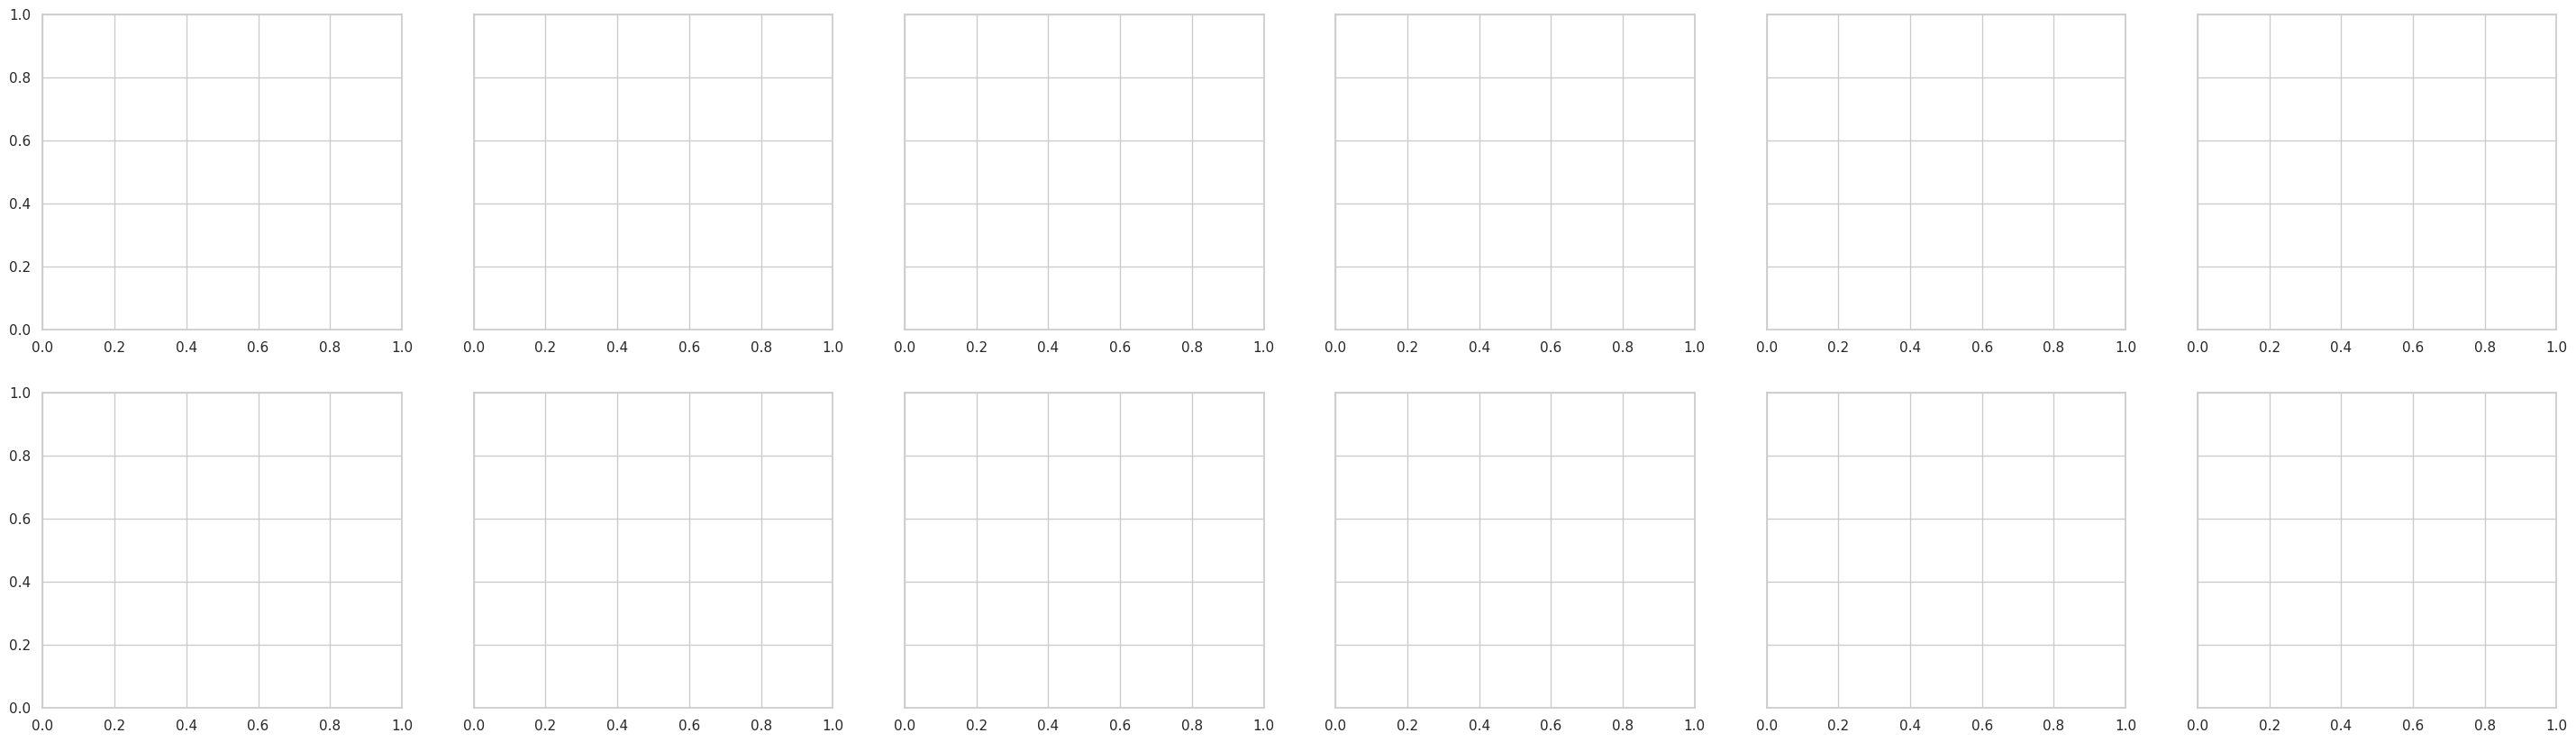

In [27]:
from src.utils.visualisation import plot_correct_incorrect_bars 

print(f" <======================Single approach======================>")
plot_correct_incorrect_bars(
    predictors,
    test_probs=results_sn['y_probs'],
    y_test=results_sn['y_labels'],
    y_entropies=results_sn['entropy'],
    alpha=alpha,
    approach_name='single',
)


In [ ]:
# from src.conformal_prediction.aps import APS
# from src.conformal_prediction.raps import RAPS
# from src.conformal_prediction.gaps import GAPS
# from src.conformal_prediction.geaps import GEAPS
# from src.conformal_prediction.saps import SAPS
# from src.conformal_prediction.eaps import EAPS


# alpha = 0.05
# predictors_sn = {
#     'APS': APS(alpha=alpha, randomize=True, probas=results_sn['y_probs'], labels=results_sn['y_labels']),
#     'SAPS': SAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_sn['y_probs'], labels=results_sn['y_labels']),
#     'RAPS': RAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_sn['y_probs'], labels=results_sn['y_labels']),
#     'GAPS': GAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_sn['y_probs'], labels=results_sn['y_labels']),
#     'GEAPS': GEAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_sn['y_probs'], labels=results_sn['y_labels']),
#     'EAPS': EAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_sn['y_probs'], labels=results_sn['y_labels']),
# }
# predictors_mcd = {
#     'APS': APS(alpha=alpha, randomize=True, probas=results_mcd['y_probs'], labels=results_mcd['y_labels']),
#     'SAPS': SAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_mcd['y_probs'], labels=results_mcd['y_labels']),
#     'RAPS': RAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_mcd['y_probs'], labels=results_mcd['y_labels']),
#     'GAPS': GAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_mcd['y_probs'], labels=results_mcd['y_labels']),
#     'GEAPS': GEAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_mcd['y_probs'], labels=results_mcd['y_labels']),
#     'EAPS': EAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_mcd['y_probs'], labels=results_mcd['y_labels']),
# }
# predictors_de = {
#     'APS': APS(alpha=alpha, randomize=True, probas=results_de['y_probs'], labels=results_de['y_trues']),
#     'RAPS': RAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_de['y_probs'], labels=results_de['y_trues']),
#     'SAPS': SAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_de['y_probs'], labels=results_de['y_trues']),
#     'GAPS': GAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_de['y_probs'], labels=results_de['y_trues']),
#     'GEAPS': GEAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_de['y_probs'], labels=results_de['y_trues']),
#     'EAPS': EAPS(alpha=alpha, k_reg=2, lambda_param=0.75, randomize=True, probas=results_de['y_probs'], labels=results_de['y_trues']),
# }

# # calibration and compute tau



In [ ]:
# get number of correctly predicted and misclassified samples with probas=results_sn['y_probs'], labels=results_sn['y_labels']
import numpy as np

def get_correctly_predicted_and_misclassified_samples(probas, labels):
    correctly_predicted = []
    misclassified = []
    predicted_classes = np.argmax(probas, axis=1)  # Get predicted classes from probabilities
    for i in range(len(predicted_classes)):
        if predicted_classes[i] == labels[i]:
            correctly_predicted.append(i)
        else:
            misclassified.append(i)
    return correctly_predicted, misclassified

correctly_predicted_sn, misclassified_sn = get_correctly_predicted_and_misclassified_samples(results_sn['y_probs'], results_sn['y_labels'])
print(f"Single Net | Number of correctly predicted samples: {len(correctly_predicted_sn)}")
print(f"Single Net | Number of misclassified samples: {len(misclassified_sn)}")

correctly_predicted_mcd, misclassified_mcd = get_correctly_predicted_and_misclassified_samples(results_mcd['y_probs'], results_mcd['y_labels'])
print(f"MC Dropout | Number of correctly predicted samples: {len(correctly_predicted_mcd)}")
print(f"MC Dropout | Number of misclassified samples: {len(misclassified_mcd)}")

correctly_predicted_de, misclassified_de = get_correctly_predicted_and_misclassified_samples(results_de['y_probs'], results_de['y_trues'])
print(f"Deep Ensemble | Number of correctly predicted samples: {len(correctly_predicted_de)}")
print(f"Deep Ensemble | Number of misclassified samples: {len(misclassified_de)}")

Single Net | Number of correctly predicted samples: 591
Single Net | Number of misclassified samples: 17
MC Dropout | Number of correctly predicted samples: 591
MC Dropout | Number of misclassified samples: 17
Deep Ensemble | Number of correctly predicted samples: 603
Deep Ensemble | Number of misclassified samples: 5



=== Calibration avec alpha=0.05 ===

📌 Méthode : APS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 0.9612

📌 Méthode : SAPS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 0.9605

📌 Méthode : RAPS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 0.9604

📌 Méthode : GAPS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 0.9674

📌 Méthode : GEAPS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 1.0000

📌 Méthode : EAPS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 0.9621


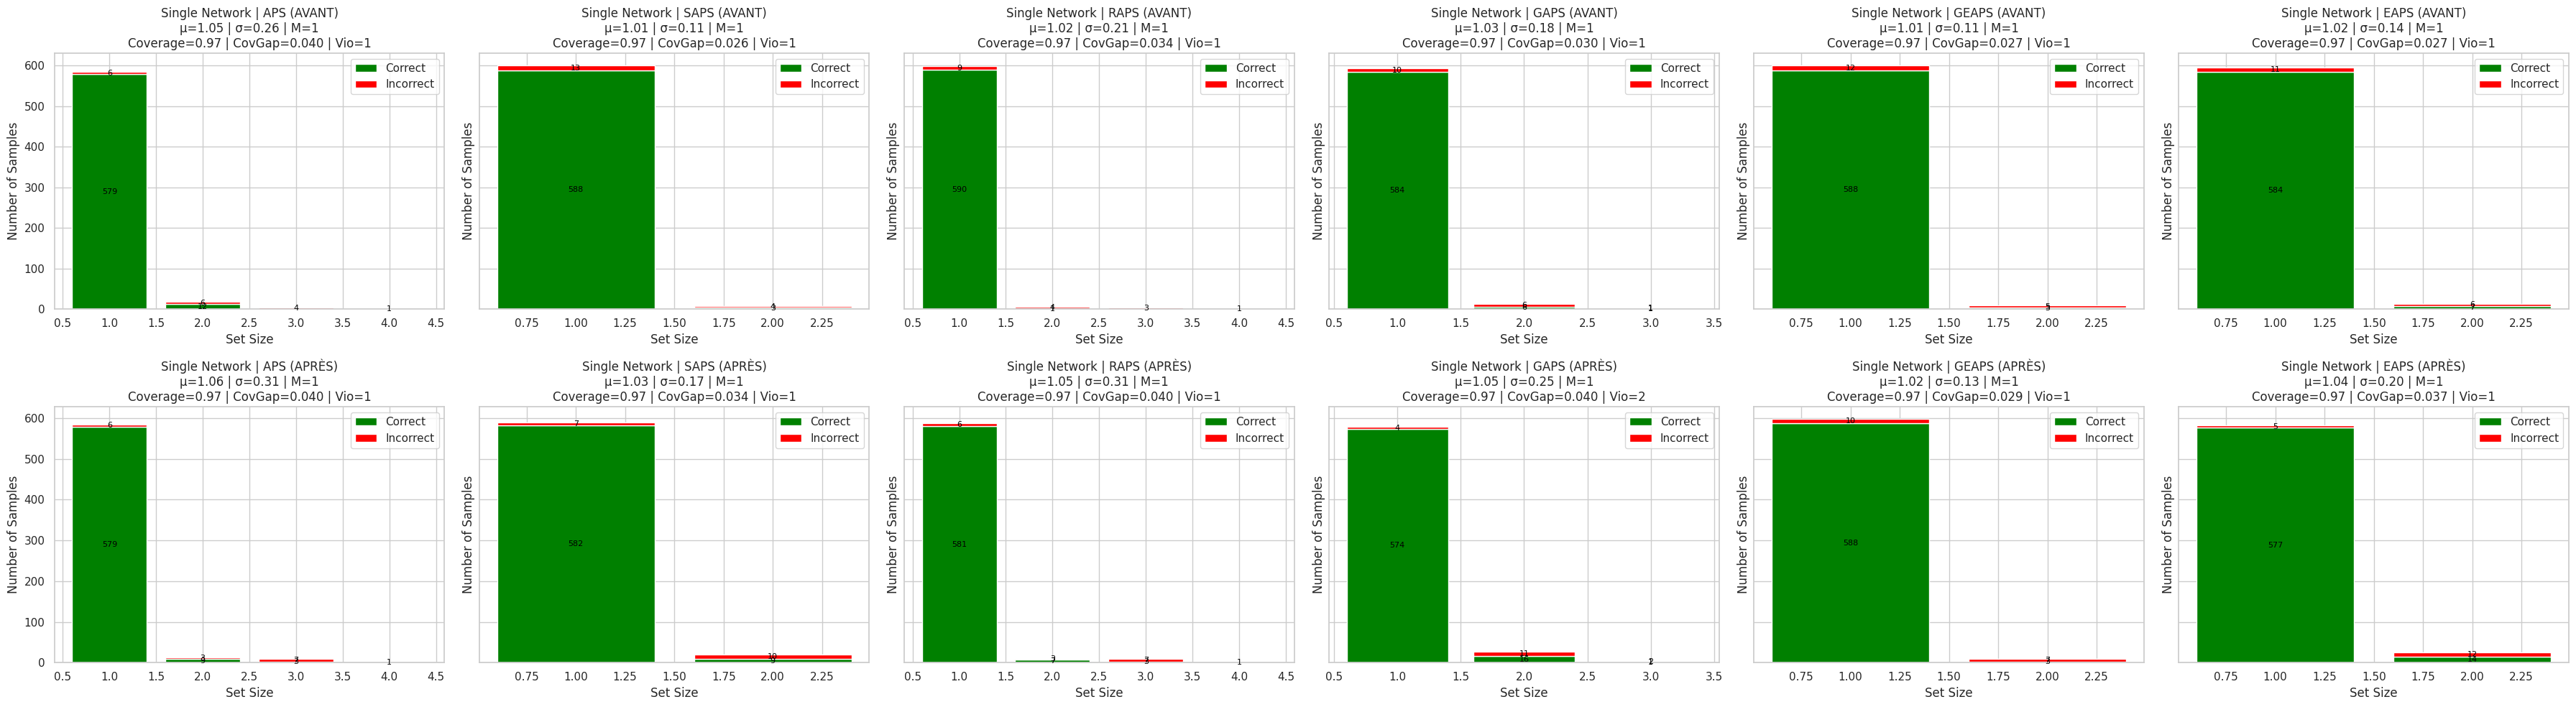


=== Calibration avec alpha=0.05 ===

📌 Méthode : APS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 0.9473

📌 Méthode : SAPS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 0.9783

📌 Méthode : RAPS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 0.9561

📌 Méthode : GAPS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 0.9538

📌 Méthode : GEAPS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 1.0000

📌 Méthode : EAPS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 0.9802


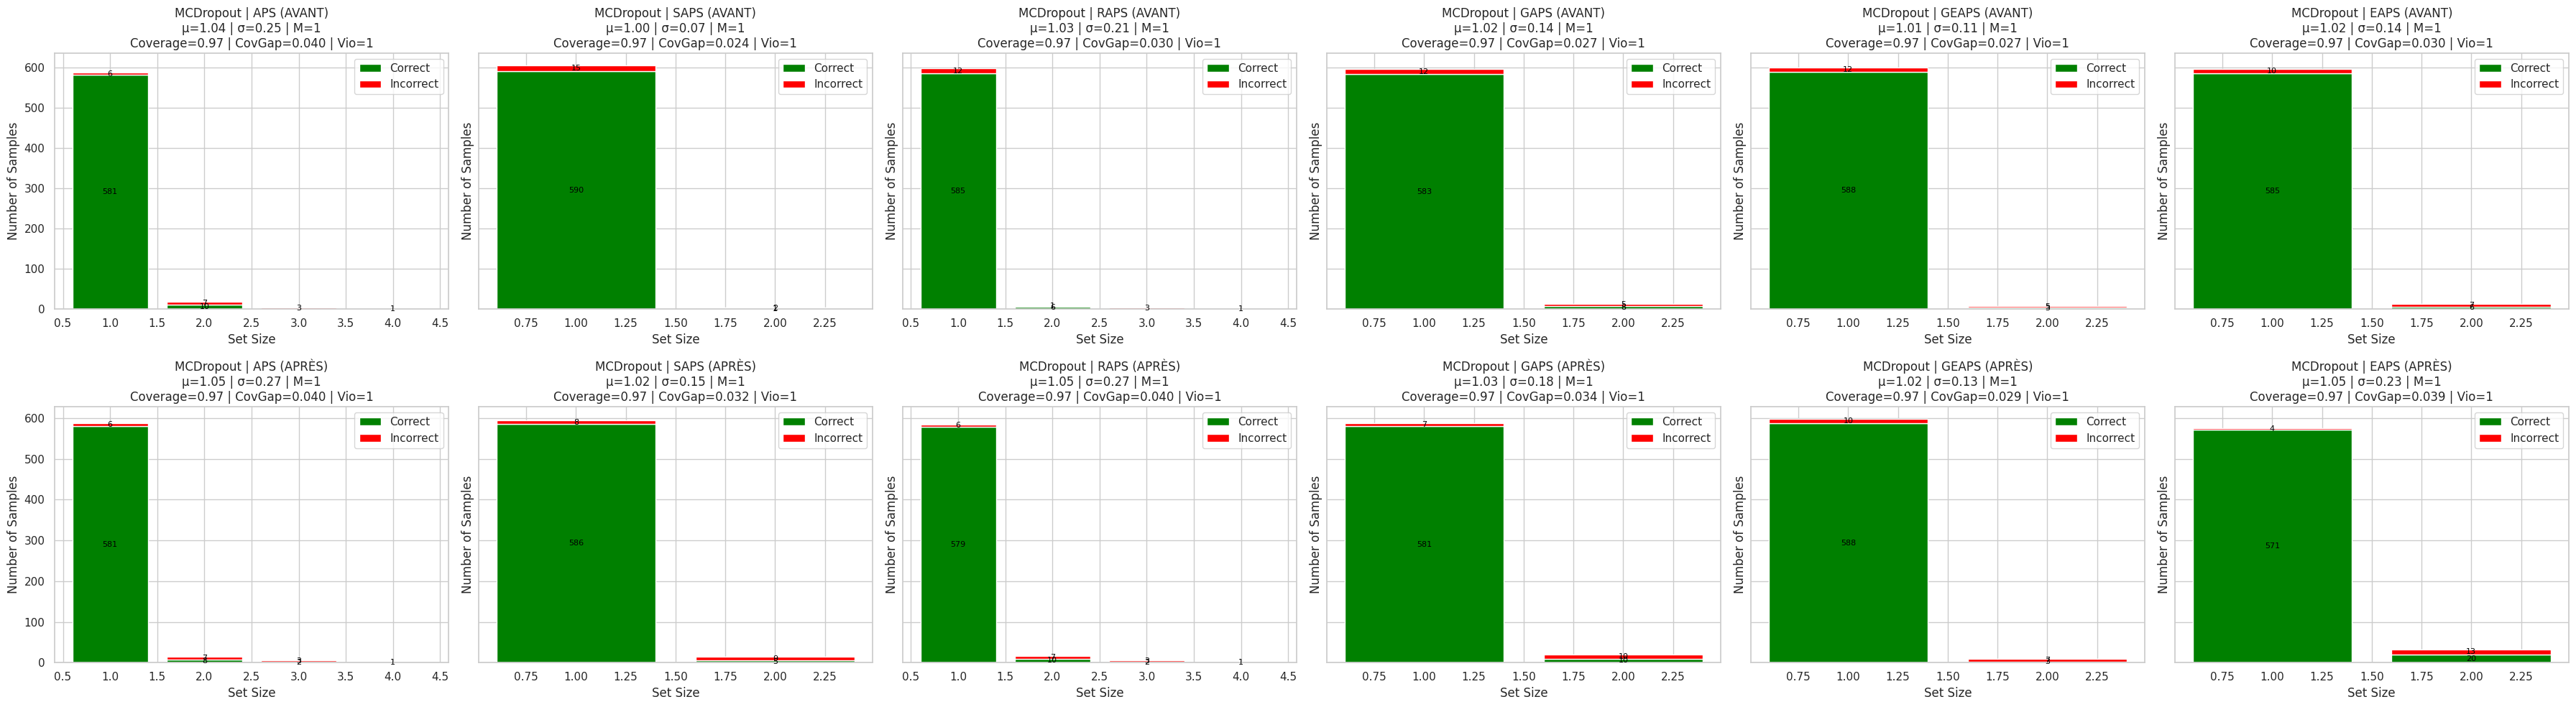


=== Calibration avec alpha=0.05 ===

📌 Méthode : APS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 0.9391

📌 Méthode : RAPS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 0.9353

📌 Méthode : SAPS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 0.9482

📌 Méthode : GAPS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 0.9497

📌 Méthode : GEAPS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 1.0000

📌 Méthode : EAPS
[DEBUG] Scores shape: (608,) | Type: <class 'numpy.ndarray'>
  ➤ Tau (threshold): 0.9282


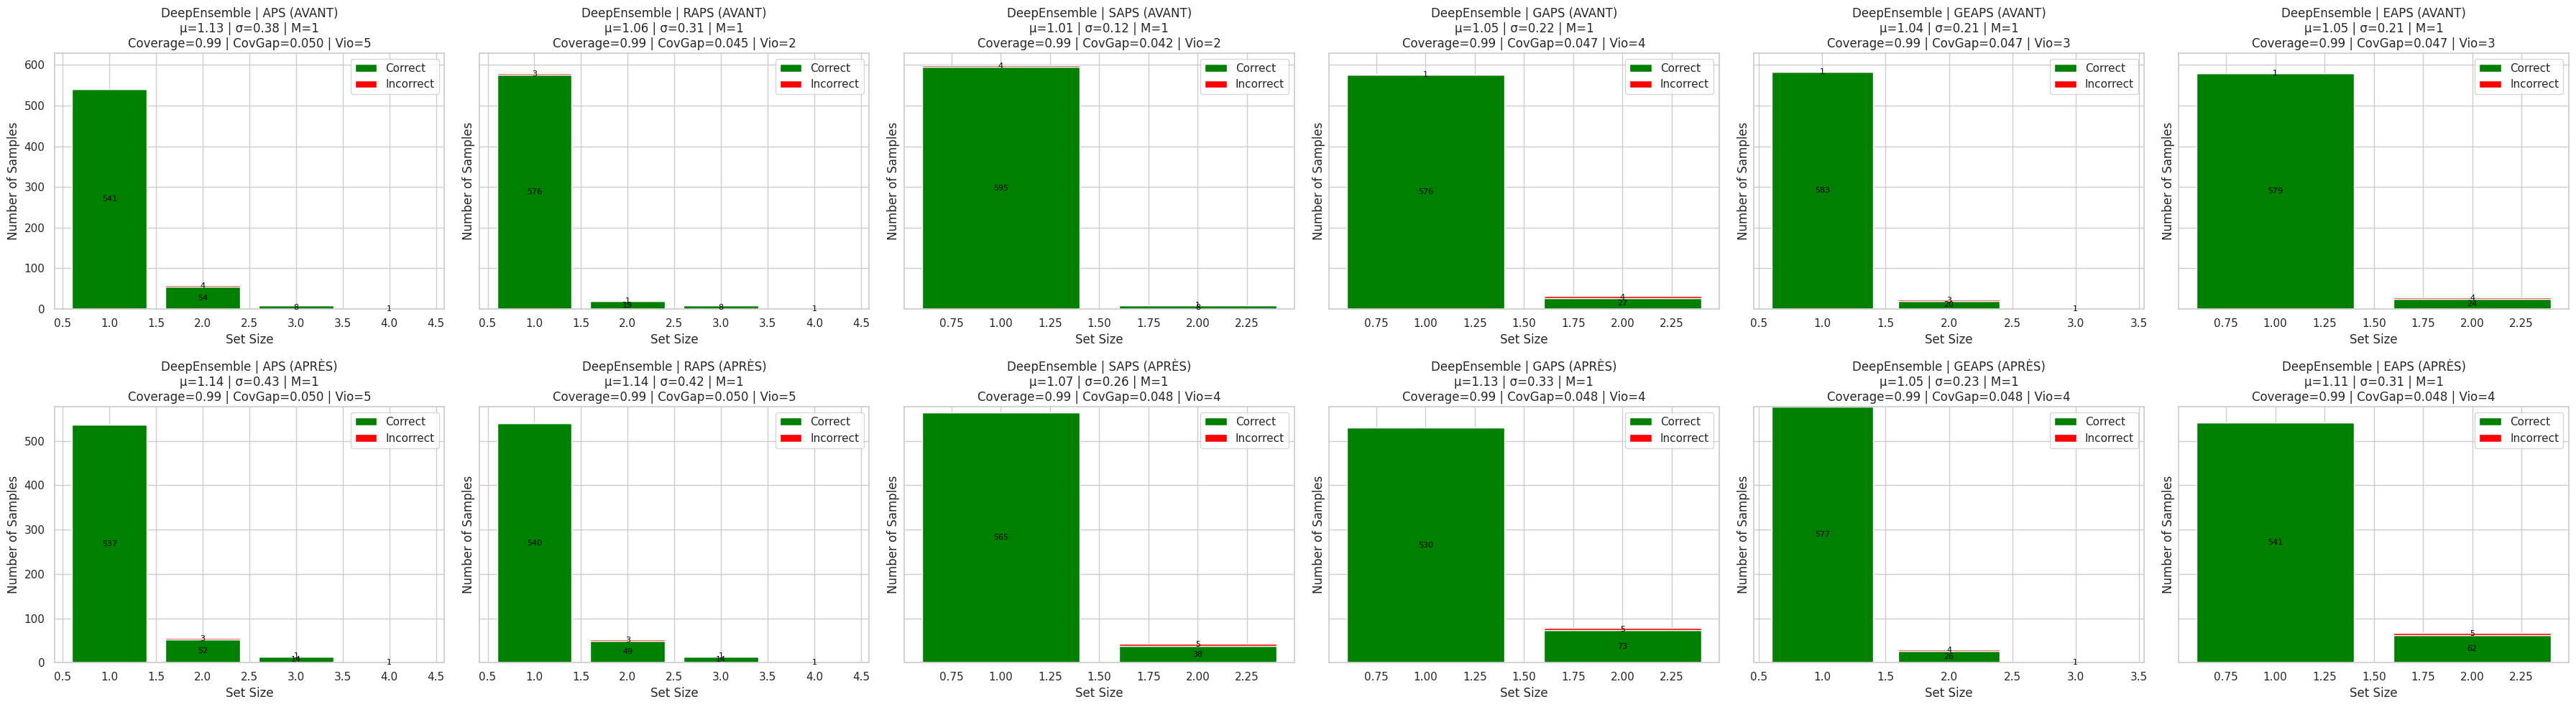

In [ ]:
# from src.utils.visualisation import plot_correct_incorrect_bars 

# def calibrate_and_visualize(predictor_dict, test_probs, test_labels, test_vars, test_entropies, alpha, approach_name=None):
#     print(f"\n=== Calibration avec alpha={alpha} ===")
#     for name, predictor in predictor_dict.items():
#         print(f"\n📌 Méthode : {name}")
#         predictor.calibrate()
#         print(f"  ➤ Tau (threshold): {predictor.threshold:.4f}")
    
#     plot_correct_incorrect_bars(
#         predictor_dict=predictor_dict,
#         test_probs=test_probs,
#         y_test=test_labels,
#         y_entropies=test_entropies,
#         alpha=alpha,
#         approach_name=approach_name
#     )
# # Pour Single Network
# calibrate_and_visualize(
#     predictor_dict=predictors_sn,
#     test_probs=results_sn['y_probs'],
#     test_labels=results_sn['y_labels'],
#     test_vars=results_sn['y_variances'],
#     test_entropies=results_sn['entropy'],
#     alpha=0.05,
#     approach_name='Single Network'
# )


# # Pour MC Dropout
# calibrate_and_visualize(
#     predictor_dict=predictors_mcd,
#     test_probs=results_mcd['y_probs'],
#     test_labels=results_mcd['y_labels'],
#     test_entropies=results_mcd['entropy'],
#     test_vars=results_mcd['y_variances'],
#     alpha=0.05,
#     approach_name='MCDropout'
# )

# # Pour Deep Ensemble
# calibrate_and_visualize(
#     predictor_dict=predictors_de,
#     test_probs=results_de['y_probs'],
#     test_labels=results_de['y_trues'],
#     test_entropies=results_de['entropy'],
#     test_vars=results_mcd['y_variances'],
#     alpha=0.05,
#     approach_name='DeepEnsemble'
# )
